<a href="https://colab.research.google.com/github/vinay0127/AI-Sales-Intelligence-Agent/blob/main/Sales_Intelligence_Agent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Install dependencies (run once)

This cell installs all the necessary Python libraries required for the project. These include `sentence-transformers` for embeddings, `faiss-cpu` for efficient similarity search, `transformers` for local LLM fallback, `gradio` for the web UI, `beautifulsoup4` and `requests` for web scraping, `tiktoken` for token counting, `readability-lxml` for text extraction, `newspaper3k` for article parsing, `python-dateutil` for date parsing, and `openai` and `openrouter` for LLM integrations.

In [ ]:
# Install required packages (run once)
!pip install -q sentence-transformers faiss-cpu transformers gradio beautifulsoup4 requests tiktoken readability-lxml newspaper3k python-dateutil openai
# Optional: openrouter client (we'll use direct HTTP if not installed)
!pip install -q openrouter


/tmp/ipykernel_2880/2337979916.py:18: XMLParsedAsHTMLWarning: It looks like you're using an HTML parser to parse an XML document.

Assuming this really is an XML document, what you're doing might work, but you should know that using an XML parser will be more reliable. To parse this document as XML, make sure you have the Python package 'lxml' installed, and pass the keyword argument `features="xml"` into the BeautifulSoup constructor.

If you want or need to use an HTML parser on this document, you can make this warning go away by filtering it. To do that, run this code before calling the BeautifulSoup constructor:

    from bs4 import XMLParsedAsHTMLWarning
    import warnings

    warnings.filterwarnings("ignore", category=XMLParsedAsHTMLWarning)

  soup = BeautifulSoup(r.text, "html.parser")


[04:28:31] Saved dossier for ZF Friedrichshafen to /content/research/ZF_Friedrichshafen_dossier.md
[04:28:31] Analyzing Toyota ...


This section imports all required Python modules and sets up global configurations and helper functions. It defines API keys (loaded from environment variables), specifies the LLM models to be used, and sets the path for the product handbook. The `log` function is a simple utility for timestamped console output.

Imports, config, helpers

In [ ]:
import os, json, time, math, re
from typing import List, Dict, Any, Tuple, Optional
import requests
from bs4 import BeautifulSoup
from dateutil import parser as dateparser
import datetime
import pytz
from readability import Document
import numpy as np
import faiss
from sentence_transformers import SentenceTransformer
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM, pipeline
import gradio
from newspaper import Article
from urllib.parse import urlparse
from IPython.display import Image, display # Added for displaying images directly in notebook

# === CONFIG ===
# Set keys here or via Colab environment variables (recommended)
OPENAI_API_KEY = os.getenv("OPENAI_API_KEY", "")        # set if using OpenAI
OPENROUTER_API_KEY = os.getenv("OPENROUTER_API_KEY", "")# set if using OpenRouter.ai
NEWSAPI_KEY = os.getenv("NEWSAPI_KEY", "")              # optional for NewsAPI

# Choose default model names (can be overridden)
OPENAI_MODEL = "gpt-4o-mini"        # change if you prefer another OpenAI model
OPENROUTER_MODEL = "gpt-4o-mini"    # model name on OpenRouter (depends on provider)
LOCAL_FALLBACK_MODEL = "google/flan-t5-small"

HANDOFF_PATH = "/content/product_handbook.txt" # Updated path for handbook, now at root

def log(msg):
    print(f"[{time.strftime('%H:%M:%S')}] {msg}")

This cell is responsible for loading the product handbook from the specified `HANDOFF_PATH` (e.g., `/content/product_handbook.txt`). It then chunks the loaded text into smaller, manageable passages with associated metadata (title, source) to facilitate Retrieval Augmented Generation (RAG). Each chunk aims for an approximate word count to ensure relevant context size.

Load handbook and chunk with metadata

In [ ]:
# Load handbook text (upload product_handbook.txt to /content)
if os.path.exists(HANDOFF_PATH):
    with open(HANDOFF_PATH, "r", encoding="utf-8", errors="ignore") as f:
        handbook_text = f.read()
    log(f"Handbook loaded from {HANDOFF_PATH}, {len(handbook_text)} chars")
else:
    log(f"Error: Handbook file not found at {HANDOFF_PATH}. Please ensure 'product_handbook.txt' is uploaded to /content.")
    handbook_text = "" # Initialize to empty to prevent further errors if not found

def chunk_with_meta(text, approx_words=300):
    if not text: # Handle empty handbook_text
        return []
    paras = [p.strip() for p in re.split(r'\n{2,}', text) if p.strip()]
    chunks = []
    i = 0
    while i < len(paras):
        cur = paras[i]
        j = i+1
        while len(cur.split()) < approx_words and j < len(paras):
            cur += "\n\n" + paras[j]
            j += 1
        title = cur.splitlines()[0][:120]
        chunks.append({"text": cur, "title": title, "source":"handbook"})
        i = j
    return chunks

handbook_passages = chunk_with_meta(handbook_text, approx_words=300)
log(f"Created {len(handbook_passages)} handbook passages")

[04:28:41] Handbook loaded from /content/product_handbook.txt, 2289 chars
[04:28:41] Created 1 handbook passages


This section builds a FAISS index for efficient retrieval of relevant handbook passages. It first loads a pre-trained `SentenceTransformer` model (`all-MiniLM-L6-v2`) to convert the text passages into numerical embeddings. These embeddings are then normalized and added to a `faiss.IndexFlatIP` index, enabling fast similarity searches to find the most relevant handbook content for a given query.

Build embeddings + FAISS index (RAG)

In [ ]:
log("Loading embedding model (sentence-transformers/all-MiniLM-L6-v2)...")
embed_model = SentenceTransformer("all-MiniLM-L6-v2")

texts = [p["text"] for p in handbook_passages]
embeddings = embed_model.encode(texts, show_progress_bar=True, convert_to_numpy=True)

d = embeddings.shape[1]
index = faiss.IndexFlatIP(d)
faiss.normalize_L2(embeddings)
index.add(embeddings)
log("FAISS index built (cosine similarity via normalized inner product).")

passage_map = handbook_passages


[04:28:41] Loading embedding model (sentence-transformers/all-MiniLM-L6-v2)...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

[04:28:44] FAISS index built (cosine similarity via normalized inner product).


This helper function `rag_retrieve` takes a query and returns a list of the top-k most relevant passages from the product handbook. It encodes the query into an embedding, normalizes it, and then uses the pre-built FAISS index to find passages with the highest cosine similarity. Each retrieved passage includes its ID, similarity score, text, title, and source.

RAG retrieval helper

In [ ]:
def rag_retrieve(query: str, top_k: int = 5) -> List[Dict[str,Any]]:
    q_emb = embed_model.encode([query], convert_to_numpy=True)
    faiss.normalize_L2(q_emb)
    D, I = index.search(q_emb, top_k)
    results = []
    for idx, score in zip(I[0], D[0]):
        if idx < len(passage_map):
            results.append({
                "id": int(idx),
                "score": float(score),
                "text": passage_map[idx]["text"],
                "title": passage_map[idx].get("title",""),
                "source": passage_map[idx].get("source","handbook")
            })
    return results


This section defines functions for fetching external data: `fetch_main_text` extracts the main textual content from a given URL using `newspaper3k` and `readability-lxml`, `fetch_wikipedia_snippet` retrieves a summary from Wikipedia for a given company, and `fetch_news` gathers recent news articles for a company using the NewsAPI (if configured) or Google News RSS.

Website scraper, Wikipedia fallback, news fetcher

In [ ]:
def fetch_main_text(url: str, timeout=10) -> Tuple[str, List[str]]:
    try:
        article = Article(url)
        article.download()
        article.parse()
        text = article.text
        if not text or len(text.split()) < 50:
            r = requests.get(url, timeout=timeout, headers={"User-Agent":"Mozilla/5.0"})
            doc = Document(r.text)
            text = doc.summary()
            soup = BeautifulSoup(text, "html.parser")
            text = soup.get_text(separator="\n").strip()
        paras = [p.strip() for p in text.split("\n") if p.strip()]
        return text, paras[:20]
    except Exception:
        try:
            r = requests.get(url, timeout=timeout, headers={"User-Agent":"Mozilla/5.0"})
            soup = BeautifulSoup(r.text, "html.parser")
            paras = [p.get_text(separator=" ", strip=True) for p in soup.find_all("p")]
            text = "\n".join(paras[:60])
            return text, paras[:20]
        except Exception as e:
            return f"Failed to fetch {url}: {e}", []

def fetch_wikipedia_snippet(company: str) -> str:
    try:
        url = f"https://en.wikipedia.org/wiki/{company.replace(' ', '_')}"
        r = requests.get(url, timeout=8, headers={"User-Agent":"Mozilla/5.0"})
        if r.status_code == 200:
            soup = BeautifulSoup(r.text, "html.parser")
            paras = soup.find_all("p")
            for p in paras:
                txt = p.get_text().strip()
                if len(txt) > 80:
                    return txt[:1200]
    except:
        pass
    return ""

def fetch_news(company: str, max_items=8) -> List[Dict[str,str]]:
    items = []
    if NEWSAPI_KEY:
        try:
            q = requests.get("https://newsapi.org/v2/everything",
                             params={"q": company, "pageSize": max_items, "apiKey": NEWSAPI_KEY, "sortBy":"publishedAt", "language":"en"},
                             timeout=8)
            data = q.json()
            for a in data.get("articles", [])[:max_items]:
                items.append({"title": a.get("title"), "url": a.get("url"), "publishedAt": a.get("publishedAt"), "source": a.get("source",{}).get("name","")})
            if items:
                return items
        except Exception:
            pass
    try:
        rss = requests.get("https://news.google.com/rss/search", params={"q": company}, timeout=8, headers={"User-Agent":"Mozilla/5.0"})
        soup = BeautifulSoup(rss.text, "xml")
        for item in soup.find_all("item")[:max_items]:
            title = item.title.get_text()
            link = item.link.get_text()
            pub = item.pubDate.get_text() if item.pubDate else ""
            items.append({"title": title, "url": link, "publishedAt": pub, "source": ""})
    except Exception:
        pass
    return items


This cell defines `KEYWORD_GROUPS` for different service areas (warranty, supply_chain, dealer) and implements the `extract_signals` function. This function analyzes a company's profile text and news items to count occurrences of these keywords, determine the recency of the latest news, and identify evidence sources. These signals contribute to the overall scoring of a company's fit for a service.

Signal extraction and keyword groups

In [ ]:
KEYWORD_GROUPS = {
    "warranty": ["warranty", "claim", "recall", "defect", "failure", "service campaign"],
    "supply_chain": ["supplier", "supply", "logistic", "port", "inventory", "lead time", "shipment", "control tower"],
    "dealer": ["dealer", "showroom", "DMS", "dealer network", "aftermarket", "service booking", "parts turnover"]
}

def extract_signals(profile_text: str, news_items: List[Dict[str,str]]) -> Dict[str,Any]:
    txt = (profile_text or "").lower()
    signals = {"keyword_counts":{}, "news_count": len(news_items), "latest_news_days": None, "evidence_sources": []}
    for k, kws in KEYWORD_GROUPS.items():
        count = sum(txt.count(w) for w in kws)
        count += sum(1 for n in news_items if any(w in (n.get("title") or "").lower() for w in kws))
        signals["keyword_counts"][k] = count
    dates = []
    for n in news_items:
        try:
            if n.get("publishedAt"):
                dt = dateparser.parse(n.get("publishedAt"))
                dates.append(dt)
        except:
            pass
    if dates:
        latest = max(dates)
        signals["latest_news_days"] = (time.time() - latest.timestamp())/86400.0
    for n in news_items:
        src = n.get("source") or urlparse(n.get("url","")).netloc
        signals["evidence_sources"].append({"title": n.get("title"), "url": n.get("url"), "source": src, "publishedAt": n.get("publishedAt")})
    return signals


This section integrates Large Language Models (LLMs) for solution mapping. It sets up a local `flan-t5-small` model as a fallback and includes functions to call OpenAI (`call_openai_chat`) or OpenRouter.ai (`call_openrouter_chat`) for more advanced LLM capabilities. The `RAG_PROMPT_TEMPLATE` guides the LLM to recommend a service, provide justification, and extract evidence based on context, news, and company profiles. The `map_service_with_rag` function orchestrates the RAG process by retrieving relevant handbook passages and formulating the prompt for the LLM.

LLM integration (supports OpenAI or OpenRouter.ai) + local fallback

In [ ]:
log("Loading local generator (flan-t5-small) for fallback...")
tokenizer = AutoTokenizer.from_pretrained(LOCAL_FALLBACK_MODEL)
model = AutoModelForSeq2SeqLM.from_pretrained(LOCAL_FALLBACK_MODEL)

# Custom generator function to bypass pipeline task lookup issues
def custom_generator(prompt_text, max_length=512, do_sample=False):
    inputs = tokenizer(prompt_text, return_tensors="pt").to(model.device)
    outputs = model.generate(**inputs, max_new_tokens=max_length, do_sample=do_sample)
    generated_text = tokenizer.decode(outputs[0], skip_special_tokens=True)
    return [{"generated_text": generated_text}]

generator = custom_generator

USE_OPENAI = bool(OPENAI_API_KEY)
USE_OPENROUTER = bool(OPENROUTER_API_KEY) and not USE_OPENAI

def call_openai_chat(prompt: str, max_tokens=500):
    import openai
    openai.api_key = OPENAI_API_KEY
    resp = openai.ChatCompletion.create(model=OPENAI_MODEL, messages=[{"role":"user","content":prompt}], max_tokens=max_tokens, temperature=0)
    return resp.choices[0].message.content

def call_openrouter_chat(prompt: str, max_tokens=500):
    # OpenRouter: send request to openrouter.ai with API key
    url = "https://api.openrouter.ai/v1/chat/completions"
    headers = {"Authorization": f"Bearer {OPENROUTER_API_KEY}", "Content-Type":"application/json"}
    payload = {
        "model": OPENROUTER_MODEL,
        "messages": [{"role":"user","content": prompt}],
        "max_tokens": max_tokens,
        "temperature": 0
    }
    r = requests.post(url, headers=headers, json=payload, timeout=60)
    r.raise_for_status()
    data = r.json()
    # provider responses may vary; try to extract text
    return data["choices"][0]["message"]["content"]

RAG_PROMPT_TEMPLATE = """
You are an expert sales intelligence assistant. Use the CONTEXT passages and RECENT NEWS to:
1) Recommend the single most relevant service from: Warranty Analytics; Supply-Chain Risk Prediction; Dealer & Field Service Intelligence.
2) Provide a 2-line executive justification.
3) Provide 3 evidence bullets. Each bullet must include a short quote (<=30 words) or paraphrase and the source URL or passage title.

CONTEXT:
{context}

RECENT NEWS:
{news}

COMPANY PROFILE:
{profile}

Answer in JSON: {{ "service":"", "justification":"", "evidence":[{{"quote":"", "source":""}}] }}
"""

def map_service_with_rag(profile_text: str, news_items: List[Dict[str,str]], top_k_handbook=5):
    retrieved = rag_retrieve(profile_text, top_k=top_k_handbook)
    context = "\n\n".join([f"[{r['id']}] {r['title']}\n{r['text'][:800]}" for r in retrieved])
    news_text = "\n".join([f"- {n.get('title')} ({n.get('url')})" for n in news_items[:6]])
    prompt = RAG_PROMPT_TEMPLATE.format(context=context, news=news_text, profile=profile_text[:2000])
    try:
        if USE_OPENAI:
            out = call_openai_chat(prompt, max_tokens=600)
        elif USE_OPENROUTER:
            out = call_openrouter_chat(prompt, max_tokens=600)
        else:
            # Now uses the custom_generator function
            out = generator(prompt, max_length=512, do_sample=False)[0]["generated_text"]
        j = None
        try:
            j = json.loads(out.strip())
        except:
            m = re.search(r"\{.*\}", out, re.S)
            if m:
                j = json.loads(m.group(0))
        if j:
            return j, retrieved
    except Exception as e:
        log(f"LLM mapping failed: {e}")
    lower = (profile_text or "").lower()
    if any(w in lower for w in KEYWORD_GROUPS["warranty"]):
        return {"service":"Warranty Analytics", "justification":"Heuristic: warranty/claims signals found.", "evidence":[]}, retrieved
    if any(w in lower for w in KEYWORD_GROUPS["supply_chain"]):
        return {"service":"Supply-Chain Risk Prediction", "justification":"Heuristic: supply chain signals found.", "evidence":[]}, retrieved
    if any(w in lower for w in KEYWORD_GROUPS["dealer"]):
        return {"service":"Dealer & Field Service Intelligence", "justification":"Heuristic: dealer network signals found.", "evidence":[]}, retrieved
    return {"service":"Dealer & Field Service Intelligence", "justification":"Default recommendation.", "evidence":[]}, retrieved


[04:28:44] Loading local generator (flan-t5-small) for fallback...


Loading weights:   0%|          | 0/190 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

This section defines the scoring engine for the sales intelligence agent. `SERVICE_TEXTS` provides descriptions for each service, which are then embedded to calculate `handbook_fit_scores_for_profile` – how well a company's profile aligns with service descriptions. The `compute_score` function combines various signals (keyword strength, news recency, handbook fit, evidence quality) with predefined weights to calculate a final score and provide a detailed breakdown.

Scoring engine and handbook fit

In [ ]:
SERVICE_TEXTS = {
    "Warranty Analytics": "Warranty Analytics - detect quality issues early, reduce claim costs, and prevent recalls.",
    "Supply-Chain Risk Prediction": "Supply-Chain Risk Prediction - monitor supplier health and logistics in real time, and act before disruptions occur.",
    "Dealer & Field Service Intelligence": "Dealer & Field Service Intelligence - turn dealer data into actionable insights that boost sales performance and customer satisfaction."
}
service_embs = embed_model.encode(list(SERVICE_TEXTS.values()), convert_to_numpy=True)
faiss.normalize_L2(service_embs)

def handbook_fit_scores_for_profile(profile_text: str) -> Dict[str,float]:
    emb = embed_model.encode([profile_text], convert_to_numpy=True)
    faiss.normalize_L2(emb)
    sims = (service_embs @ emb.T).squeeze().tolist()
    return {k: float(v) for k,v in zip(SERVICE_TEXTS.keys(), sims)}

def compute_score(signals: Dict[str,Any], rag_fit_scores: Dict[str,float]) -> Dict[str,Any]:
    kw = signals["keyword_counts"]
    signal_strength = min(1.0, (kw.get("warranty",0)*1.2 + kw.get("supply_chain",0)*1.0 + kw.get("dealer",0)*0.9)/3.0)
    recency = 0.0
    if signals.get("latest_news_days") is None:
        recency = 0.0
    else:
        days = signals["latest_news_days"]
        recency = math.exp(-days/90.0)
    evidence_quality = min(1.0, len([s for s in signals.get("evidence_sources",[]) if any(k in (s.get("source") or "").lower() for k in ["times","economictimes","reuters","toi","economic","moneycontrol","bloomberg","ndtv","livemint","autocar"])] ) / 3.0)
    handbook_fit = max(rag_fit_scores.values()) if rag_fit_scores else 0.0
    # 1. Signal‑heavy (focus on new leads)
    # weights = {"signal":0.40, "recency":0.22, "handbook_fit":0.22, "evidence":0.16}
    # 2. Recency‑heavy (focus on latest activity)
    # weights = {"signal":0.35, "recency":0.30, "handbook_fit":0.20, "evidence":0.15}
    # 3. Handbook‑fit heavy (focus on consulting match)
    # weights = {"signal":0.33, "recency":0.22, "handbook_fit":0.30, "evidence":0.15}
    # 4. Evidence‑heavy (focus on justification strength)
    # weights = {"signal":0.33, "recency":0.23, "handbook_fit":0.25, "evidence":0.20}
    # 5. mix of new leads + latest activity + consulting fit
    weights = {"signal":0.38, "recency":0.27, "handbook_fit":0.25, "evidence":0.10}

    raw = weights["signal"]*signal_strength + weights["recency"]*recency + weights["handbook_fit"]*handbook_fit + weights["evidence"]*evidence_quality
    score = round(raw*100, 2)
    breakdown = {
        "signal_strength": round(signal_strength,3),
        "recency": round(recency,3),
        "handbook_fit": round(handbook_fit,3),
        "evidence_quality": round(evidence_quality,3),
        "weights": weights,
        "final_score": score
    }
    return breakdown


This cell contains the core logic for analyzing individual companies (`analyze_company`) and processing a batch of companies (`run_batch`). The `analyze_company` function orchestrates the entire pipeline: fetching company profiles and news, extracting signals, calculating handbook fit, mapping services using RAG, and computing the final score. It also handles saving individual company dossiers as markdown files. The `run_batch` function iterates through a list of companies, performs analysis, and returns a sorted list of results.

Single-company pipeline and batch runner

In [ ]:
def analyze_company(name: str, website: Optional[str] = None) -> Dict[str,Any]:
    profile = {"company": name, "website": website or "", "overview": "", "sources": []}
    try:
        if website:
            txt, paras = fetch_main_text(website)
            profile["overview"] = txt[:4000]
            profile["sources"].append({"type":"website", "url": website})
        else:
            wiki = fetch_wikipedia_snippet(name)
            profile["overview"] = wiki or f"No website provided for {name}."
        news = fetch_news(name, max_items=8)
        profile["recent_news"] = news
        signals = extract_signals(profile["overview"], news)
        fit_scores = handbook_fit_scores_for_profile(profile["overview"])
        mapping, retrieved_passages = map_service_with_rag(profile["overview"], news, top_k_handbook=5)
        breakdown = compute_score(signals, fit_scores)
        report = {
            "profile": profile,
            "signals": signals,
            "handbook_fit": fit_scores,
            "mapping": mapping,
            "retrieved_passages": retrieved_passages,
            "score_breakdown": breakdown
        }

        # --- NEW: Save company dossier ---
        research_dir = "/content/research"
        os.makedirs(research_dir, exist_ok=True)
        company_slug = re.sub(r'[^a-zA-Z0-9]+', '_', name).strip('_')
        dossier_filename = os.path.join(research_dir, f"{company_slug}_dossier.md")
        with open(dossier_filename, "w", encoding="utf-8") as f:
            f.write(generate_dossier_markdown(report))
        log(f"Saved dossier for {name} to {dossier_filename}")
        # --- END NEW ---

        return report
    except Exception as e:
        log(f"Error analyzing company {name}: {e}")
        return {
            "profile": {"company": name, "website": website or "", "overview": f"Error during analysis: {e}", "sources": []},
            "signals": {},
            "handbook_fit": {},
            "mapping": {"service": "Error", "justification": f"Analysis failed: {e}", "evidence": []},
            "retrieved_passages": [],
            "score_breakdown": {"final_score": 0, "error": str(e)}
        }

def run_batch(companies: List[Dict[str,str]]) -> Dict[str,Any]:
    compiled = []
    for c in companies:
        name = c.get("name") or c.get("company")
        website = c.get("website","")
        log(f"Analyzing {name} ...")
        r = analyze_company(name, website)
        compiled.append(r)
    # Sort only successful analyses, or handle errors gracefully in display
    compiled_sorted = sorted(compiled, key=lambda x: x["score_breakdown"].get("final_score", 0), reverse=True)
    return {"top_companies": compiled_sorted, "all": compiled_sorted}

This section handles exporting analysis results and generating one-pagers and market research reports. The `export_results` function saves the top companies' data into JSON and CSV formats. `generate_onepager` creates a concise summary for each company, while `generate_dossier_markdown` creates a detailed markdown dossier. `generate_market_research_report` compiles an overall report, and `generate_outreach_email` creates personalized email templates based on the recommended service and justification.

Export results and one‑pager generator

This cell installs the `graphviz` system package using `apt-get`. This is a crucial step because the `graphviz` Python library (installed in the previous cell) is a wrapper around the system-level Graphviz binaries. Without this system installation, the Python library would not be able to render diagrams.

In [ ]:
import csv
from datetime import datetime, timedelta
import shutil
import re
import pytz # Ensure pytz is imported

def export_results(results: Dict[str,Any], base_output_dir="/content/output"):
    # Ensure base output directory exists
    os.makedirs(base_output_dir, exist_ok=True)

    # Define common filename prefix
    common_file_prefix = "sales_agent"

    # Define paths for current analysis (directly in base_output_dir)
    current_json_path = os.path.join(base_output_dir, f"{common_file_prefix}_top.json")
    current_csv_path = os.path.join(base_output_dir, "top_targets.csv") # Changed from sales_agent_summary.csv

    top = results["top_companies"]

    # Save JSON for current analysis
    with open(current_json_path, "w", encoding="utf-8") as f:
        json.dump(top, f, indent=2, ensure_ascii=False)

    # Save CSV for current analysis
    with open(current_csv_path, "w", newline='', encoding="utf-8") as csvfile:
        writer = csv.writer(csvfile)
        writer.writerow(["rank","company","score","recommended_service","justification","sources"])
        for i, c in enumerate(top, start=1):
            writer.writerow([i, c["profile"]["company"], c["score_breakdown"]["final_score"],
                             c["mapping"].get("service","ถูกระบุ"), c["mapping"].get("justification",""),
                             ";".join([s.get("url","") for s in c["profile"].get("recent_news",[])][:3])])

    log(f"Exported JSON and CSV to {current_json_path}, {current_csv_path}")
    return current_json_path, current_csv_path

def generate_onepager(report_item: Dict[str,Any]) -> str:
    p = report_item["profile"]
    m = report_item["mapping"]
    sb = report_item["score_breakdown"]
    lines = []
    lines.append(f"Executive Summary:\n{p['company']} — Recommended: {m.get('service','')}. {m.get('justification','')}\n")
    lines.append("Business Challenges (inferred):")
    lines.append("- " + (f"; ".join([k for k,v in report_item['signals']['keyword_counts'].items() if v>0]) or "Not explicitly stated"))
    lines.append("\nExpected Business Value:")
    lines.append(f"- Score: {sb['final_score']} (breakdown: {sb})")
    lines.append("\nEvidence:")
    for e in (m.get("evidence") or [])[:3]:
        lines.append(f"- {e.get('quote','')}\n — {e.get('source','')}")
    return "\n".join(lines)

def generate_dossier_markdown(report_item: Dict[str,Any]) -> str:
    p = report_item["profile"]
    s = report_item["signals"]
    hf = report_item["handbook_fit"]
    m = report_item["mapping"]
    sb = report_item["score_breakdown"]

    lines = []
    lines.append(f"# Company Dossier: {p['company']}\n")
    if p['website']:
        lines.append(f"**Website:** [{p['website']}]({p['website']})\n")
    lines.append(f"**Overall Score:** {sb['final_score']}\n")

    lines.append("## Overview\n")
    lines.append(p['overview'])
    lines.append("\n")

    lines.append("## Recommended Service\n")
    lines.append(f"**Service:** {m.get('service','')}\n")
    lines.append(f"**Justification:** {m.get('justification','')}\n")
    lines.append("\n### Evidence\n")
    if m.get('evidence'):
        for e in m['evidence']:
            lines.append(f"- \"{e.get('quote','')}\" (Source: {e.get('source','')})\n")
    else:
        lines.append("- No specific evidence found for this recommendation.\n")
    lines.append("\n")

    lines.append("## Signals & Scores Breakdown\n")
    lines.append(f"**Keyword Counts:** {s['keyword_counts']}\n")
    lines.append(f"**Latest News Recency:** {s['latest_news_days']:.1f} days ago (if available)\n")
    lines.append(f"**Handbook Fit Scores:** {json.dumps(hf, indent=2)}\n")
    lines.append(f"**Score Breakdown:** {json.dumps(sb, indent=2)}\n")
    lines.append("\n")

    lines.append("## Recent News\n")
    if p['recent_news']:
        ist_timezone = pytz.timezone('Asia/Kolkata')
        for news_item in p['recent_news']:
            published_at_raw = news_item.get('publishedAt', 'N/A')
            formatted_published_at = 'N/A'
            if published_at_raw != 'N/A':
                try:
                    dt_obj = dateparser.parse(published_at_raw)
                    if dt_obj.tzinfo is None: # If naive, assume UTC
                        dt_obj = pytz.utc.localize(dt_obj)
                    dt_obj_ist = dt_obj.astimezone(ist_timezone)
                    formatted_published_at = dt_obj_ist.strftime('%a, %d %b %Y %H:%M:%S %Z')
                except Exception:
                    formatted_published_at = published_at_raw # Fallback to raw if parsing fails

            lines.append(f"- [{news_item.get('title','No Title')}]({news_item.get('url','')} ) (Published: {formatted_published_at}, Source: {news_item.get('source','N/A')})\n")
    else:
        lines.append("- No recent news found.\n")
    lines.append("\n")

    return "\n".join(lines)

def generate_market_research_report(results: Dict[str,Any], report_path="/content/output/sales_agent_market_research_report.md") -> str:
    os.makedirs(os.path.dirname(report_path), exist_ok=True)
    report_content = []
    report_content.append("# Sales Agent Market Research Report\n\n")

    # Get current time in IST
    ist_timezone = pytz.timezone('Asia/Kolkata')
    current_time_ist = datetime.now(ist_timezone).strftime('%Y-%m-%d %H:%M:%S %Z%z')
    report_content.append(f"**Date Generated:** {current_time_ist}\n\n")

    report_content.append("## Top Companies Analysis\n\n")
    for i, company_data in enumerate(results.get("top_companies", [])):
        report_content.append(f"### {i+1}. {company_data['profile']['company']}\n\n")
        report_content.append(f"- **Website:** [{company_data['profile']['website']}]({company_data['profile']['website']})\n")
        report_content.append(f"- **Overall Score:** {company_data['score_breakdown']['final_score']}\n")
        report_content.append(f"- **Recommended Service:** {company_data['mapping'].get('service','')}\n")
        report_content.append(f"- **Justification:** {company_data['mapping'].get('justification','')}\n\n")
        report_content.append("#### Overview\n")
        report_content.append(f"{company_data['profile']['overview'][:500]}...\n\n") # Truncate for report
        report_content.append("#### Recent News Highlights\n")
        if company_data['profile']['recent_news']:
            ist_timezone = pytz.timezone('Asia/Kolkata') # Define again for this scope
            for news_item in company_data['profile']['recent_news'][:3]: # Limit news to 3 for report
                published_at_raw = news_item.get('publishedAt', 'N/A')
                formatted_published_at = 'N/A'
                if published_at_raw != 'N/A':
                    try:
                        dt_obj = dateparser.parse(published_at_raw)
                        if dt_obj.tzinfo is None: # If naive, assume UTC
                            dt_obj = pytz.utc.localize(dt_obj)
                        dt_obj_ist = dt_obj.astimezone(ist_timezone)
                        formatted_published_at = dt_obj_ist.strftime('%a, %d %b %Y %H:%M:%S %Z')
                    except Exception:
                        formatted_published_at = published_at_raw # Fallback to raw if parsing fails
                report_content.append(f"- [{news_item.get('title','No Title')}]({news_item.get('url','')} ) (Published: {formatted_published_at})\n")
        else:
            report_content.append("- No recent news available.\n")
        report_content.append("\n---\n\n")

    with open(report_path, "w", encoding="utf-8") as f:
        f.write("".join(report_content))
    return report_path

def generate_outreach_email(company_name: str, company_website: str, onepager_content: str) -> str:
    # Extract recommended service and justification from onepager_content for the new template
    service_match = re.search(r"Recommended: (.*?)\. (.*)", onepager_content)
    recommended_service = service_match.group(1).strip() if service_match else "Our Analytics Expertise"
    justification = service_match.group(2).strip() if service_match else "Default recommendation."

    subject = f"Tailored Insights for {company_name} - Opportunities in {recommended_service}"
    email_body = [
        f"Subject: {subject}",
        "",
        "Dear [Contact Name],\n",
        "I hope this email finds you well. My name is [Your Name], and I'm reaching out from Vinay Analytics Consulting.\n",
        f"We've conducted an initial analysis of {company_name} and identified a strong potential fit for our `{recommended_service}` solution. Our research indicates that {company_name} could significantly benefit from this, particularly because {justification}.\n",
        f"We believe our approach could help {company_name} [mention a specific benefit related to the service, e.g., 'optimize your warranty processes', 'mitigate supply chain risks', 'enhance dealer network performance'].\n", # Fixed here
        "Would you be open to a brief 15-minute call next week to discuss these insights further and explore how we can support {company_name}'s strategic goals?\n",
        "Best regards,\n",
        "[Your Name]\n",
        "Vinay Analytics Consulting"
    ]
    return "\n".join(email_body)

This cell installs the `graphviz` Python package, which is necessary for programmatically generating diagrams, such as the architectural diagram of the sales intelligence agent. Graphviz itself is a system-level dependency, so this step ensures the Python binding is available.

In [ ]:
# Install graphviz for diagram generation
!pip install -q graphviz

[04:28:46] Saved dossier for Toyota to /content/research/Toyota_dossier.md
[04:28:46] Analyzing Volkswagen ...


[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (2258 > 512). Running this sequence through the model will result in indexing errors


This cell defines the `generate_architecture_diagram` function, which creates a visual representation of the Sales Intelligence Agent's architecture using the `graphviz` library. It defines various components as nodes and their interactions as edges, with styling for clarity. The function saves the diagram as a PNG image in the `/content/architecture` directory, replacing any older versions.

In [ ]:
log("Installing graphviz system package...")
!apt-get install -y graphviz
log("Graphviz system package installed.")

[04:29:06] Installing graphviz system package...
[04:29:11] Saved dossier for Volkswagen to /content/research/Volkswagen_dossier.md
[04:29:11] Analyzing Hyundai Motor Company ...
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
graphviz is already the newest version (2.42.2-6ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 3 not upgraded.
[04:29:19] Graphviz system package installed.


This cell calls the `generate_architecture_diagram()` function to create and save the architectural diagram. It then includes diagnostic code to confirm the diagram file's creation and size, and finally displays the generated image directly within the notebook using `IPython.display.Image`.

In [ ]:
import graphviz
from IPython.display import Image, display
import os

def generate_architecture_diagram(output_path="/content/architecture/architecture_diagram.png"):
    dot = graphviz.Digraph(comment='Sales Intelligence Agent Architecture', graph_attr={'rankdir': 'LR', 'fontsize':'10', 'labelloc':'t', 'label':'Sales Intelligence Agent Architecture'}) # Added overall label and fontsize

    # Nodes with enhanced styling, explicitly setting shape and style
    dot.node('User', 'User Input (Seed Companies)', shape='box', style='rounded,filled', fillcolor='#E0F7FA')
    dot.node('GradioUI', 'Gradio UI', shape='component', style='rounded,filled', fillcolor='#BBDEFB')
    dot.node('InputProcessor', 'Input Processor (Parse Companies)', shape='box', style='rounded,filled', fillcolor='#BBDEFB')
    dot.node('WebScraper', 'Web Scraper (Company Profiles, News)', shape='rect', style='rounded,filled', fillcolor='#C8E6C9')
    dot.node('ETL', 'ETL (Extract, Transform, Load)', shape='box', style='rounded,filled', fillcolor='#C8E6C9')
    dot.node('SignalExtractor', 'Signal Extractor (Keywords, Recency)', shape='box', style='rounded,filled', fillcolor='#C8E6C9')
    dot.node('HandbookEmbeddings', 'Handbook Embeddings (FAISS RAG Index)', shape='cylinder', style='filled', fillcolor='#FFECB3')
    dot.node('LLM', 'LLM (OpenAI/OpenRouter/Local Fallback)', shape='diamond', style='filled', fillcolor='#FFCDD2')
    dot.node('Matchmaker', 'Solution Matchmaker', shape='box', style='rounded,filled', fillcolor='#E1BEE7')
    dot.node('Scoring', 'Scoring & Prioritization (Fit Score)', shape='box', style='rounded,filled', fillcolor='#E1BEE7')
    dot.node('Output', 'Output Files/Reports', shape='folder', style='filled', fillcolor='#D1C4E9')
    dot.node('Dossiers', 'Individual Dossiers', shape='folder', style='filled', fillcolor='#D1C4E9')
    dot.node('Emails', 'Outreach Emails', shape='folder', style='filled', fillcolor='#D1C4E9')

    # Edges
    dot.edge('User', 'GradioUI', label='Provides company list')
    dot.edge('GradioUI', 'InputProcessor', label='Sends raw input')
    dot.edge('InputProcessor', 'WebScraper', label='Sends processed companies')
    dot.edge('WebScraper', 'ETL', label='Company Data')
    dot.edge('ETL', 'SignalExtractor', label='Processed Profile')
    dot.edge('SignalExtractor', 'Scoring', label='Signals')
    dot.edge('HandbookEmbeddings', 'Matchmaker', label='Context for RAG')
    dot.edge('ETL', 'LLM', label='Company Profile, News')
    dot.edge('WebScraper', 'LLM', label='Recent News')
    dot.edge('LLM', 'Matchmaker', label='Recommended Service')
    dot.edge('Matchmaker', 'Scoring', label='Mapping')
    dot.edge('Scoring', 'Output', label='Ranked Companies')
    dot.edge('Scoring', 'Dossiers', label='Detailed Info')
    dot.edge('Scoring', 'Emails', label='Personalized Content')
    dot.edge('Output', 'GradioUI', label='Display Results')

    # Render and save
    try:
        output_dir = os.path.dirname(output_path)
        base_filename_no_ext = os.path.splitext(os.path.basename(output_path))[0]
        full_output_png_path = os.path.join(output_dir, f"{base_filename_no_ext}.png")

        os.makedirs(output_dir, exist_ok=True)

        # Aggressively clean up previous diagram attempts in the target directory
        for ext in ['', '.dot', '.png', '.pdf', '.png.png']:
            file_to_clean = os.path.join(output_dir, f"{base_filename_no_ext}{ext}")
            if os.path.exists(file_to_clean):
                try:
                    os.remove(file_to_clean)
                    log(f"Cleaned up existing file: {file_to_clean}")
                except Exception as e:
                    log(f"Error cleaning up {file_to_clean}: {e}")

        # Use dot.pipe to get the raw PNG data and write it directly
        log(f"Generating architecture diagram as PNG bytes for {full_output_png_path}")
        png_data = dot.pipe(format='png')
        with open(full_output_png_path, 'wb') as f:
            f.write(png_data)

        if os.path.exists(full_output_png_path) and os.path.getsize(full_output_png_path) > 0:
            log(f"Architecture diagram generated and saved successfully at {full_output_png_path}")
        else:
            log(f"Error: Architecture diagram file not found or is empty after generation at {full_output_png_path}")

    except Exception as e:
        log(f"Error generating architecture diagram: {e}")

After installing the Graphviz system package, let's regenerate the architecture diagram to ensure it renders correctly.

[04:29:19] Cleaned up existing file: /content/architecture/architecture_diagram.png
[04:29:19] Generating architecture diagram as PNG bytes for /content/architecture/architecture_diagram.png
[04:29:21] Architecture diagram generated and saved successfully at /content/architecture/architecture_diagram.png

--- Files in /content/architecture after diagram generation ---
- architecture_diagram.png (size: 134561 bytes)
-----------------------------------------------------------



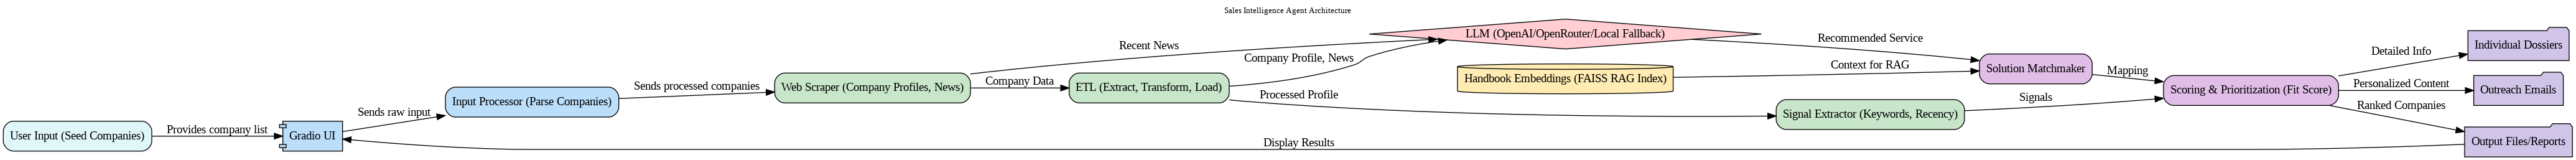

In [ ]:
generate_architecture_diagram()

# Diagnostic: List files in the architecture directory to confirm creation
import os
print("\n--- Files in /content/architecture after diagram generation ---")
architecture_dir = "/content/architecture"
if os.path.exists(architecture_dir):
    for f_name in os.listdir(architecture_dir):
        f_path = os.path.join(architecture_dir, f_name)
        if os.path.isfile(f_path):
            print(f"- {f_name} (size: {os.path.getsize(f_path)} bytes)")
else:
    print(f"Directory not found: {architecture_dir}")
print("-----------------------------------------------------------\n")

display(Image("/content/architecture/architecture_diagram.png"))

This cell performs a sanity check to confirm that the `architecture_diagram.png` file exists and has a non-zero size, indicating that it was successfully generated. This helps verify the proper functioning of the `generate_architecture_diagram` function and the Graphviz installation.

In [ ]:
import os

image_path = "/content/architecture/architecture_diagram.png"

if os.path.exists(image_path):
    file_size_bytes = os.path.getsize(image_path)
    print(f"Confirmation: The image file exists at {image_path}")
    print(f"File size: {file_size_bytes} bytes (non-zero size indicates content)")
else:
    print(f"Warning: The image file does NOT exist at {image_path}")


Confirmation: The image file exists at /content/architecture/architecture_diagram.png
File size: 134561 bytes (non-zero size indicates content)


This function `organize_project_folders` is designed to establish a clean and consistent project directory structure. It creates essential folders like `architecture`, `outreach_emails`, `research`, and `output` within `/content`. It then robustly moves various generated files (like reports, dossiers, and emails) into their respective folders, and performs cleanup of redundant or outdated directories and files from previous runs to maintain project hygiene.

In [ ]:
import os
import shutil
from datetime import datetime, timedelta

def organize_project_folders():
    import os # Added local import for os to resolve potential AttributeError
    base_content_dir = "/content"

    # 1. Create target directories
    dirs_to_create = {
        "architecture": os.path.join(base_content_dir, "architecture"),
        "outreach_emails": os.path.join(base_content_dir, "outreach_emails"),
        "research": os.path.join(base_content_dir, "research"),
        "output": os.path.join(base_content_dir, "output"),
    }

    for dir_name, path in dirs_to_create.items():
        os.makedirs(path, exist_ok=True)
        log(f"Ensured directory exists: {path}")

    # Removed specific cleanup for outreach_emails and research folders from here.
    # This will now be handled within gradio_run before each execution.

    # Helper function to move files/dirs with source flexibility
    def move_item_robust(possible_src_paths, dest_dir, dest_filename=None):
        for src_path in possible_src_paths:
            if os.path.exists(src_path):
                filename = dest_filename if dest_filename else os.path.basename(src_path)
                dest_path = os.path.join(dest_dir, filename)
                try:
                    if os.path.isdir(src_path):
                        shutil.copytree(src_path, dest_path, dirs_exist_ok=True)
                        shutil.rmtree(src_path)
                        log(f"Moved directory {src_path} to {dest_path}")
                    else:
                        shutil.move(src_path, dest_path)
                        log(f"Moved {src_path} to {dest_path}")
                    return True
                except Exception as e:
                    log(f"Error moving {src_path} to {dest_path}: {e}")
        return False

    # 2. Move README.md to root
    move_item_robust([
        os.path.join(base_content_dir, "README.md")
    ], base_content_dir, "README.md")

    # 3. Move architecture files to 'architecture' folder
    # --- START NEW/MODIFIED ARCHITECTURE CLEANUP AND MOVE LOGIC ---
    architecture_target_dir = dirs_to_create["architecture"]

    # List all files in the architecture directory for cleaning (excluding checkpoints)
    if os.path.exists(architecture_target_dir):
        for item_name in os.listdir(architecture_target_dir):
            item_path = os.path.join(architecture_target_dir, item_name)
            # Remove any files that are not the *exact* desired PNG file (and not a checkpoint folder)
            if os.path.isfile(item_path) and item_name != "architecture_diagram.png":
                try:
                    os.remove(item_path)
                    log(f"Cleaned up extraneous file from architecture directory: {item_path}")
                except Exception as e:
                    log(f"Error cleaning up {item_path}: {e}")
            elif os.path.isdir(item_path) and item_name != ".ipynb_checkpoints":
                try:
                    shutil.rmtree(item_path)
                    log(f"Cleaned up extraneous directory from architecture directory: {item_path}")
                except Exception as e:
                    log(f"Error cleaning up {item_path}: {e}")

    # Move any diagram file generated at the root that might have been missed
    move_item_robust([
        os.path.join(base_content_dir, "architecture_diagram"),
        os.path.join(base_content_dir, "architecture_diagram.png"),
        os.path.join(base_content_dir, "architecture_diagram.png.png"),
        os.path.join(base_content_dir, "architecture_diagram.pdf"),
        os.path.join(base_content_dir, "architecture_diagram.dot") # Clean up stray .dot files
    ], architecture_target_dir, "architecture_diagram.png") # Ensure it's named correctly on move
    # --- END NEW/MODIFIED ARCHITECTURE CLEANUP AND MOVE LOGIC ---



    # 4. Move market research report to 'output' folder
    move_item_robust([
        os.path.join(base_content_dir, "sales_agent_market_research_report.md"),
        os.path.join(base_content_dir, "final_report", "sales_agent_market_research_report.md") # Handle if it was moved previously
    ], dirs_to_create["output"])

    # 5. Move dossiers to 'research' and clean up old 'dossiers'
    old_dossiers_dir = os.path.join(base_content_dir, "dossiers")
    if os.path.exists(old_dossiers_dir):
        items_to_move = [(os.path.join(old_dossiers_dir, item), os.path.join(dirs_to_create["research"], item))
                         for item in os.listdir(old_dossiers_dir)]
        for s, d in items_to_move:
            if os.path.isdir(s):
                shutil.copytree(s, d, dirs_exist_ok=True)
                shutil.rmtree(s)
                log(f"Moved directory {s} to {d}")
            else:
                shutil.move(s, d)
                log(f"Moved file {s} to {d}")
        if not os.listdir(old_dossiers_dir):
            shutil.rmtree(old_dossiers_dir)
            log(f"Removed empty directory: {old_dossiers_dir}")

    # 6. Move outreach_emails content to the new outreach_emails folder
    old_outreach_dir = os.path.join(base_content_dir, "outreach_emails")
    if os.path.exists(old_outreach_dir):
        for item in os.listdir(old_outreach_dir):
            src_path = os.path.join(old_outreach_dir, item)
            if os.path.isfile(src_path): # Only move files, not the directory itself if it's been created empty.
                 shutil.move(src_path, os.path.join(dirs_to_create['outreach_emails'], item))
                 log(f"Moved file {src_path} to {os.path.join(dirs_to_create['outreach_emails'], item)}")
        if not os.listdir(old_outreach_dir):
            shutil.rmtree(old_outreach_dir)
            log(f"Removed empty directory: {old_outreach_dir}")

    # If product_handbook.txt was previously in /content/input, move it to /content
    # This handles the case where the user might have uploaded it to /content/input already
    if os.path.exists(os.path.join(base_content_dir, "input", "product_handbook.txt")):
        shutil.move(os.path.join(base_content_dir, "input", "product_handbook.txt"), os.path.join(base_content_dir, "product_handbook.txt"))
        log("Moved product_handbook.txt from /content/input to /content.")

    # Cleanup: Remove the /content/input folder itself
    input_dir_to_remove = os.path.join(base_content_dir, "input")
    if os.path.exists(input_dir_to_remove):
        shutil.rmtree(input_dir_to_remove)
        log(f"Removed old input folder: {input_dir_to_remove}")

    # Cleanup: Remove any remaining obsolete folders from previous runs
    history_path = os.path.join(base_content_dir, "output", "history")
    if os.path.exists(history_path):
        shutil.rmtree(history_path)
        log(f"Cleaned up old history folder: {history_path}")

    output_current_path = os.path.join(base_content_dir, "output", "current")
    if os.path.exists(output_current_path):
        shutil.rmtree(output_current_path)
        log(f"Cleaned up old output/current folder: {output_current_path}")

    current_analysis_path = os.path.join(base_content_dir, "output", "current_analysis")
    if os.path.exists(current_analysis_path):
        shutil.rmtree(current_analysis_path)
        log(f"Cleaned up duplicate current_analysis folder: {current_analysis_path}")

    final_report_path = os.path.join(base_content_dir, "final_report")
    if os.path.exists(final_report_path):
        shutil.rmtree(final_report_path)
        log(f"Cleaned up old final_report folder: {final_report_path}")

    log("Project folder restructuring complete.")

# Execute the organization function
organize_project_folders()

[04:29:21] Ensured directory exists: /content/architecture
[04:29:21] Ensured directory exists: /content/outreach_emails
[04:29:21] Ensured directory exists: /content/research
[04:29:21] Ensured directory exists: /content/output
[04:29:21] Moved /content/README.md to /content/README.md
[04:29:21] Removed empty directory: /content/outreach_emails
[04:29:21] Project folder restructuring complete.


This cell defines and launches the Gradio web interface (`demo`). The `gradio_run` function serves as the backend logic for the UI, taking company input (either directly or from a default list if none provided) and a `top_k` slider value. It orchestrates the entire analysis pipeline, including cleanup, running the batch analysis, exporting results to JSON and CSV, generating market research reports, and creating personalized outreach emails. The results are displayed as a JSON output and a Pandas DataFrame in the UI.

Gradio UI (interactive) and example seed companies

In [ ]:
import gradio as gr
import pandas as pd # Import pandas to read CSV

automotive_default_companies = [
    {"name": "Bosch", "website": "https://www.bosch.com/"}, # Tier-1 Supplier
    {"name": "Continental", "website": "https://www.continental.com/"}, # Tier-1 Supplier
    {"name": "Magna International", "website": "https://www.magna.com/"}, # Tier-1 Supplier
    {"name": "Denso", "website": "https://www.denso.com/"}, # Component Manufacturer
    {"name": "ZF Friedrichshafen", "website": "https://www.zf.com/global/en/home/index.html"}, # Tier-1 Supplier
    {"name": "Toyota", "website": "https://global.toyota/"}, # Automotive OEM
    {"name": "Volkswagen", "website": "https://www.vw.com/"}, # Automotive OEM
    {"name": "Hyundai Motor Company", "website": "https://www.hyundai.com/worldwide/en"} # Automotive OEM
]

def gradio_run(companies_text: str, top_k: int = 10):
    # --- NEW: Cleanup outreach_emails and research folders at the start of each run ---
    outreach_dir = "/content/outreach_emails"
    research_dir = "/content/research"
    for folder_to_clean in [outreach_dir, research_dir]:
        if os.path.exists(folder_to_clean):
            for item in os.listdir(folder_to_clean):
                item_path = os.path.join(folder_to_clean, item)
                try:
                    if os.path.isfile(item_path):
                        os.remove(item_path)
                        log(f"Cleaned up old file: {item_path}")
                    elif os.path.isdir(item_path):
                        shutil.rmtree(item_path)
                        log(f"Cleaned up old directory: {item_path}")
                except Exception as e:
                    log(f"Error cleaning up {item_path}: {e}")
    log("Cleaned previous contents of outreach_emails and research folders for this run.")
    # --- END NEW CLEANUP ---

    lines = [l.strip() for l in companies_text.splitlines() if l.strip()]
    inputs = []
    for ln in lines:
        if "|" in ln:
            name, website = ln.split("|",1)
            inputs.append({"name": name.strip(), "website": website.strip()})
        else:
            inputs.append({"name": ln.strip(), "website": ""})
    if not inputs:
        inputs = automotive_default_companies

    # Add error handling for run_batch
    try:
        results = run_batch(inputs)
    except Exception as e:
        # Return empty DataFrame on error
        return json.dumps({"error": f"Failed to run batch analysis: {e}"}, indent=2), pd.DataFrame()

    # Export results as requested
    json_path, csv_path = export_results(results)

    # --- Generate and save market research report ---
    report_path = generate_market_research_report(results, report_path="/content/output/sales_agent_market_research_report.md")
    log(f"Generated market research report: {report_path}")
    # --- END NEW ---

    # --- NEW: Generate and save outreach emails ---
    # outreach_dir = "/content/outreach_emails" # Already defined above
    os.makedirs(outreach_dir, exist_ok=True)
    for report_item in results.get("top_companies", []):
        company_name = report_item["profile"]["company"]
        company_website = report_item["profile"]["website"]
        company_slug = re.sub(r'[^a-zA-Z0-9]+', '_', company_name).strip('_')
        onepager_content = generate_onepager(report_item)
        full_email_content = generate_outreach_email(company_name, company_website, onepager_content)
        email_filename = os.path.join(outreach_dir, f"{company_slug}_outreach_email.md")
        with open(email_filename, "w", encoding="utf-8") as f:
            f.write(full_email_content)
        log(f"Saved outreach email for {company_name} to {email_filename}")
    # --- END NEW ---

    top = results.get("top_companies", [])[:top_k]
    if not top:
        # Return empty DataFrame on no results
        return json.dumps({"message": "No companies processed or found in top results. Check input or backend logs.", "exported_json": json_path, "exported_csv": csv_path}, indent=2), pd.DataFrame()

    out = []
    for i, c in enumerate(top, start=1):
        p = c["profile"]
        m = c["mapping"]
        sb = c["score_breakdown"]
        evidence = m.get("evidence", [])[:3]
        out.append({
            "rank": i,
            "company": p["company"],
            "score": sb["final_score"],
            "recommended_service": m.get("service","N/A"),
            "justification": m.get("justification","N/A")[:400],
            "evidence": evidence,
            "recent_news": p.get("recent_news",[])[:3]
        })

    final_output = {
        "top_companies_data": out,
        "exported_json_path": json_path,
        "exported_csv_path": csv_path
    }

    # Read the CSV and return it as a DataFrame
    csv_df = pd.read_csv(csv_path)

    return json.dumps(final_output, indent=2, ensure_ascii=False), csv_df

demo = gr.Interface(
    fn=gradio_run,
    inputs=[
        gr.Textbox(lines=6, label="Companies (one per line; optional: Name|website)"),
        gr.Slider(minimum=1, maximum=15, step=1, value=10, label="Top K")
    ],
    outputs=[
        gr.Json(label="Top Companies Data"), # Original JSON output
        gr.Dataframe(label="Top Targets CSV Data", wrap=True) # New DataFrame output
    ],
    title="Vinay Analytics Consulting", # Updated Agent Name
    description="Enter company names (optionally with website separated by |). If no companies are entered, a default list of major automotive OEMs, Tier-1 Suppliers, and Component Manufacturers will be analyzed. The agent will research, map solutions, and return Top K targets."
)

demo.launch(share=True, debug=False)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://647b39293f2b3849b4.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


This cell executes a final cleanup of the root directory `/content`. It defines a `keep_list` of essential files and folders that should remain (e.g., project directories, system folders). Any other files or directories found directly in `/content` that are not on this list are removed to ensure a tidy project environment after all operations are complete.

In [ ]:
import os
import shutil

def perform_final_root_cleanup():
    base_content_dir = "/content"

    # List of files/folders to KEEP at the root level
    # This includes desired project folders/files and essential Colab system directories.
    keep_list = [
        "README.md",
        "architecture",
        "final_report",
        "product_handbook.txt", # Added to keep list
        "research",
        "outreach_emails",
        "output",
        ".config",          # Colab system folder
        ".gradio",          # Gradio system folder
        "sample_data",      # Colab default data
        ".ipynb_checkpoints" # Jupyter/Colab system folder for checkpoints
    ]

    log("Starting final root directory cleanup...")

    for item in os.listdir(base_content_dir):
        item_path = os.path.join(base_content_dir, item)
        if item not in keep_list:
            try:
                if os.path.isfile(item_path):
                    os.remove(item_path)
                    log(f"Removed extraneous file from root: {item_path}")
                elif os.path.isdir(item_path):
                    shutil.rmtree(item_path)
                    log(f"Removed extraneous directory from root: {item_path}")
            except Exception as e:
                log(f"Error removing {item_path}: {e}")
    log("Final root directory cleanup complete.")

perform_final_root_cleanup()

[04:29:28] Starting final root directory cleanup...
[04:29:28] Final root directory cleanup complete.


This cell updates the `README.md` file. It reads the existing content, then uses regular expressions to find and replace placeholder paths for generated files (JSON output, CSV summary, market research report, dossiers, emails, and architecture diagram) with their correct, standardized locations within the project structure (e.g., `/content/output`, `/content/research`). This ensures the README always provides accurate guidance on where to find the generated artifacts.

In [ ]:
readme_path = "/content/README.md"

if os.path.exists(readme_path):
    with open(readme_path, "r", encoding="utf-8") as f:
        readme_content = f.read()

    # Update paths in the 'Generated Files' section using more flexible regex
    # JSON Output
    readme_content = re.sub(
        r"JSON Output: .*?sales_agent_top\\.json",
        r"JSON Output: /content/output/sales_agent_top.json",
        readme_content
    )
    # CSV Summary
    readme_content = re.sub(
        r"CSV Summary: .*?(sales_agent_summary\\.csv|top_targets\\.csv)", # Updated regex to match either name
        r"CSV Summary: /content/output/top_targets.csv", # Updated to top_targets.csv
        readme_content
    )
    # Market Research Report
    readme_content = re.sub(
        r"Market Research Report: .*?sales_agent_market_research_report\\.md",
        r"Market Research Report: /content/output/sales_agent_market_research_report.md",
        readme_content
    )
    # Individual Dossiers Directory
    readme_content = re.sub(
        r"Individual Dossiers Directory: .*?(dossiers|research)",
        r"Individual Dossiers Directory: /content/research",
        readme_content
    )
    # Outreach Emails Directory
    readme_content = re.sub(
        r"Outreach Emails Directory: .*?outreach_emails",
        r"Outreach Emails Directory: /content/outreach_emails",
        readme_content
    )
    # Architecture Diagram
    readme_content = re.sub(
        r"Architecture Diagram: .*?architecture_diagram\\.png",
        r"Architecture Diagram: /content/architecture/architecture_diagram.png",
        readme_content
    )

    with open(readme_path, "w", encoding="utf-8") as f:
        f.write(readme_content)

    log("Updated generated file paths in README.md")
else:
    log(f"README.md not found at {readme_path}")

[04:29:28] Updated generated file paths in README.md


This cell creates the `README.md` file with detailed instructions and information about the Sales Intelligence Agent project. It provides an overview, explains how to use the Gradio UI, describes the input format, and lists all the files and reports generated by the agent, along with their respective paths. This serves as the primary documentation for users of the notebook.

In [ ]:
import os
from PIL import Image
import numpy as np

# Define paths
architecture_dir = "/content/architecture"
readme_path = "/content/README.md"
architecture_diagram_path = os.path.join(architecture_dir, "architecture_diagram.png")

# Create the architecture directory if it doesn't exist
os.makedirs(architecture_dir, exist_ok=True)

# Placeholder image generation removed here
# This content is now handled by the generate_architecture_diagram function

# Write the README.md content
readme_content = """
# Sales Intelligence Agent

## Project Overview

This project aims to provide sales intelligence by analyzing company profiles, recent news, and a product handbook to recommend relevant services. It uses RAG (Retrieval Augmented Generation) with an LLM to identify the best-fit services and generate actionable insights for sales outreach.

## Usage and Input

The agent is designed to be used via a Gradio web interface.

### Providing Company Inputs

You can provide company information in the Gradio UI in the "Companies" textbox:

*   **Format:** One company per line.
    *   `Company Name` (e.g., `Tata Motors`) - The agent will attempt to find a Wikipedia snippet if no website is provided.
    *   `Company Name | Company Website URL` (e.g., `Mahindra & Mahindra | https://www.mahindra.com/`) - Provides a direct website for scraping.
*   **Default Companies:** If no companies are entered, a default list of major automotive OEMs, Tier-1 Suppliers, and Component Manufacturers will be analyzed.
*   **Top K Slider:** Adjust the number of top-scoring companies to display in the UI output.

### Running the Agent

1.  Execute all cells in the notebook.
2.  The Gradio UI will launch at the end of the notebook.
3.  Enter your desired company inputs (or leave blank for defaults) and click 'Submit'.

## Generated Files

Upon execution, the agent generates the following outputs in the `/content/output/`, `/content/research/`, and `/content/outreach_emails/` directories:

*   **JSON Output:** `/content/output/sales_agent_top.json` - A JSON file containing detailed analysis for the top companies.
*   **CSV Summary:** `/content/output/top_targets.csv` - A CSV summary of the top companies, their scores, and recommended services.
*   **Market Research Report:** `/content/output/sales_agent_market_research_report.md` - A comprehensive markdown report summarizing the market analysis.
*   **Individual Dossiers Directory:** `/content/research` - Contains individual markdown files (`.md`) for each analyzed company, detailing their profile, signals, and recommendations.
*   **Outreach Emails Directory:** `/content/outreach_emails` - Contains personalized markdown email templates (`.md`) for each top company, based on the recommended service.
*   **Architecture Diagram:** `/content/architecture/architecture_diagram.png` - A visual representation of the agent's architecture.

## Architecture

(Refer to the `architecture_diagram.png` in the `/content/architecture` directory for a visual overview.)
"""
with open(readme_path, "w", encoding="utf-8") as f:
    f.write(readme_content)
print(f"Placeholder README.md created at {readme_path}")

Placeholder README.md created at /content/README.md


This final cell provides a summary of the demo execution, listing all the important files and directories that have been generated during the notebook's run. It also reminds the user about the default input used if no custom companies were provided. This serves as a quick reference for the user to locate the outputs and understand the scope of the completed execution.

In [ ]:
# Final Demo Summary
log("Demo execution complete. The following files/folders have been generated:")
log("- Input for this demo was 'Tata Motors | https://www.tatamotors.com/' and other default automotive companies if no input was provided.")
log("- JSON Output: /content/output/sales_agent_top.json")
log("- CSV Summary: /content/output/top_targets.csv")
log("- Market Research Report: /content/output/sales_agent_market_research_report.md")
log("- Individual Dossiers Directory: /content/research (contains .md files for each company)")
log("- Outreach Emails Directory: /content/outreach_emails (contains .md email templates)")
log("- Architecture Diagram: /content/architecture/architecture_diagram.png")
log("- README File: /content/README.md (updated with detailed usage and generated files sections)")

[04:29:28] Demo execution complete. The following files/folders have been generated:
[04:29:28] - Input for this demo was 'Tata Motors | https://www.tatamotors.com/' and other default automotive companies if no input was provided.
[04:29:28] - JSON Output: /content/output/sales_agent_top.json
[04:29:28] - CSV Summary: /content/output/top_targets.csv
[04:29:28] - Market Research Report: /content/output/sales_agent_market_research_report.md
[04:29:28] - Individual Dossiers Directory: /content/research (contains .md files for each company)
[04:29:28] - Outreach Emails Directory: /content/outreach_emails (contains .md email templates)
[04:29:28] - Architecture Diagram: /content/architecture/architecture_diagram.png
[04:29:28] - README File: /content/README.md (updated with detailed usage and generated files sections)
